In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Dataset
print("Loading dataset...")
df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/faers_combined_cleaned_pure_reactions.csv')

Loading dataset...


In [4]:
# Count each row
print("Calculating counts per patient...")

def count_elements(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0
    return len([item for item in str(text).split(';') if item.strip()])

# Apply counting function to every patient case row
df['drug_count'] = df['drug_combination'].apply(count_elements)
df['adr_count'] = df['adrs'].apply(count_elements)

Calculating counts per patient...


In [7]:
mean_drugs = df['drug_count'].mean()
median_drugs = df['drug_count'].median()
mode_drugs = df['drug_count'].mode()[0]

mean_adrs = df['adr_count'].mean()
median_adrs = df['adr_count'].median()
mode_adrs = df['adr_count'].mode()[0]

print("\n--- DRUG STATS PER PATIENT ---")
print(f"Mean (Average):   {mean_drugs:.2f}")
print(f"Median (Typical): {median_drugs:.1f}")
print(f"Mode (Most Freq): {mode_drugs}")

print("\n--- SIDE EFFECT (ADR) STATS PER PATIENT ---")
print(f"Mean (Average):   {mean_adrs:.2f}")
print(f"Median (Typical): {median_adrs:.1f}")
print(f"Mode (Most Freq): {mode_adrs}")


--- DRUG STATS PER PATIENT ---
Mean (Average):   3.41
Median (Typical): 1.0
Mode (Most Freq): 1

--- SIDE EFFECT (ADR) STATS PER PATIENT ---
Mean (Average):   3.14
Median (Typical): 2.0
Mode (Most Freq): 1



Generating charts...


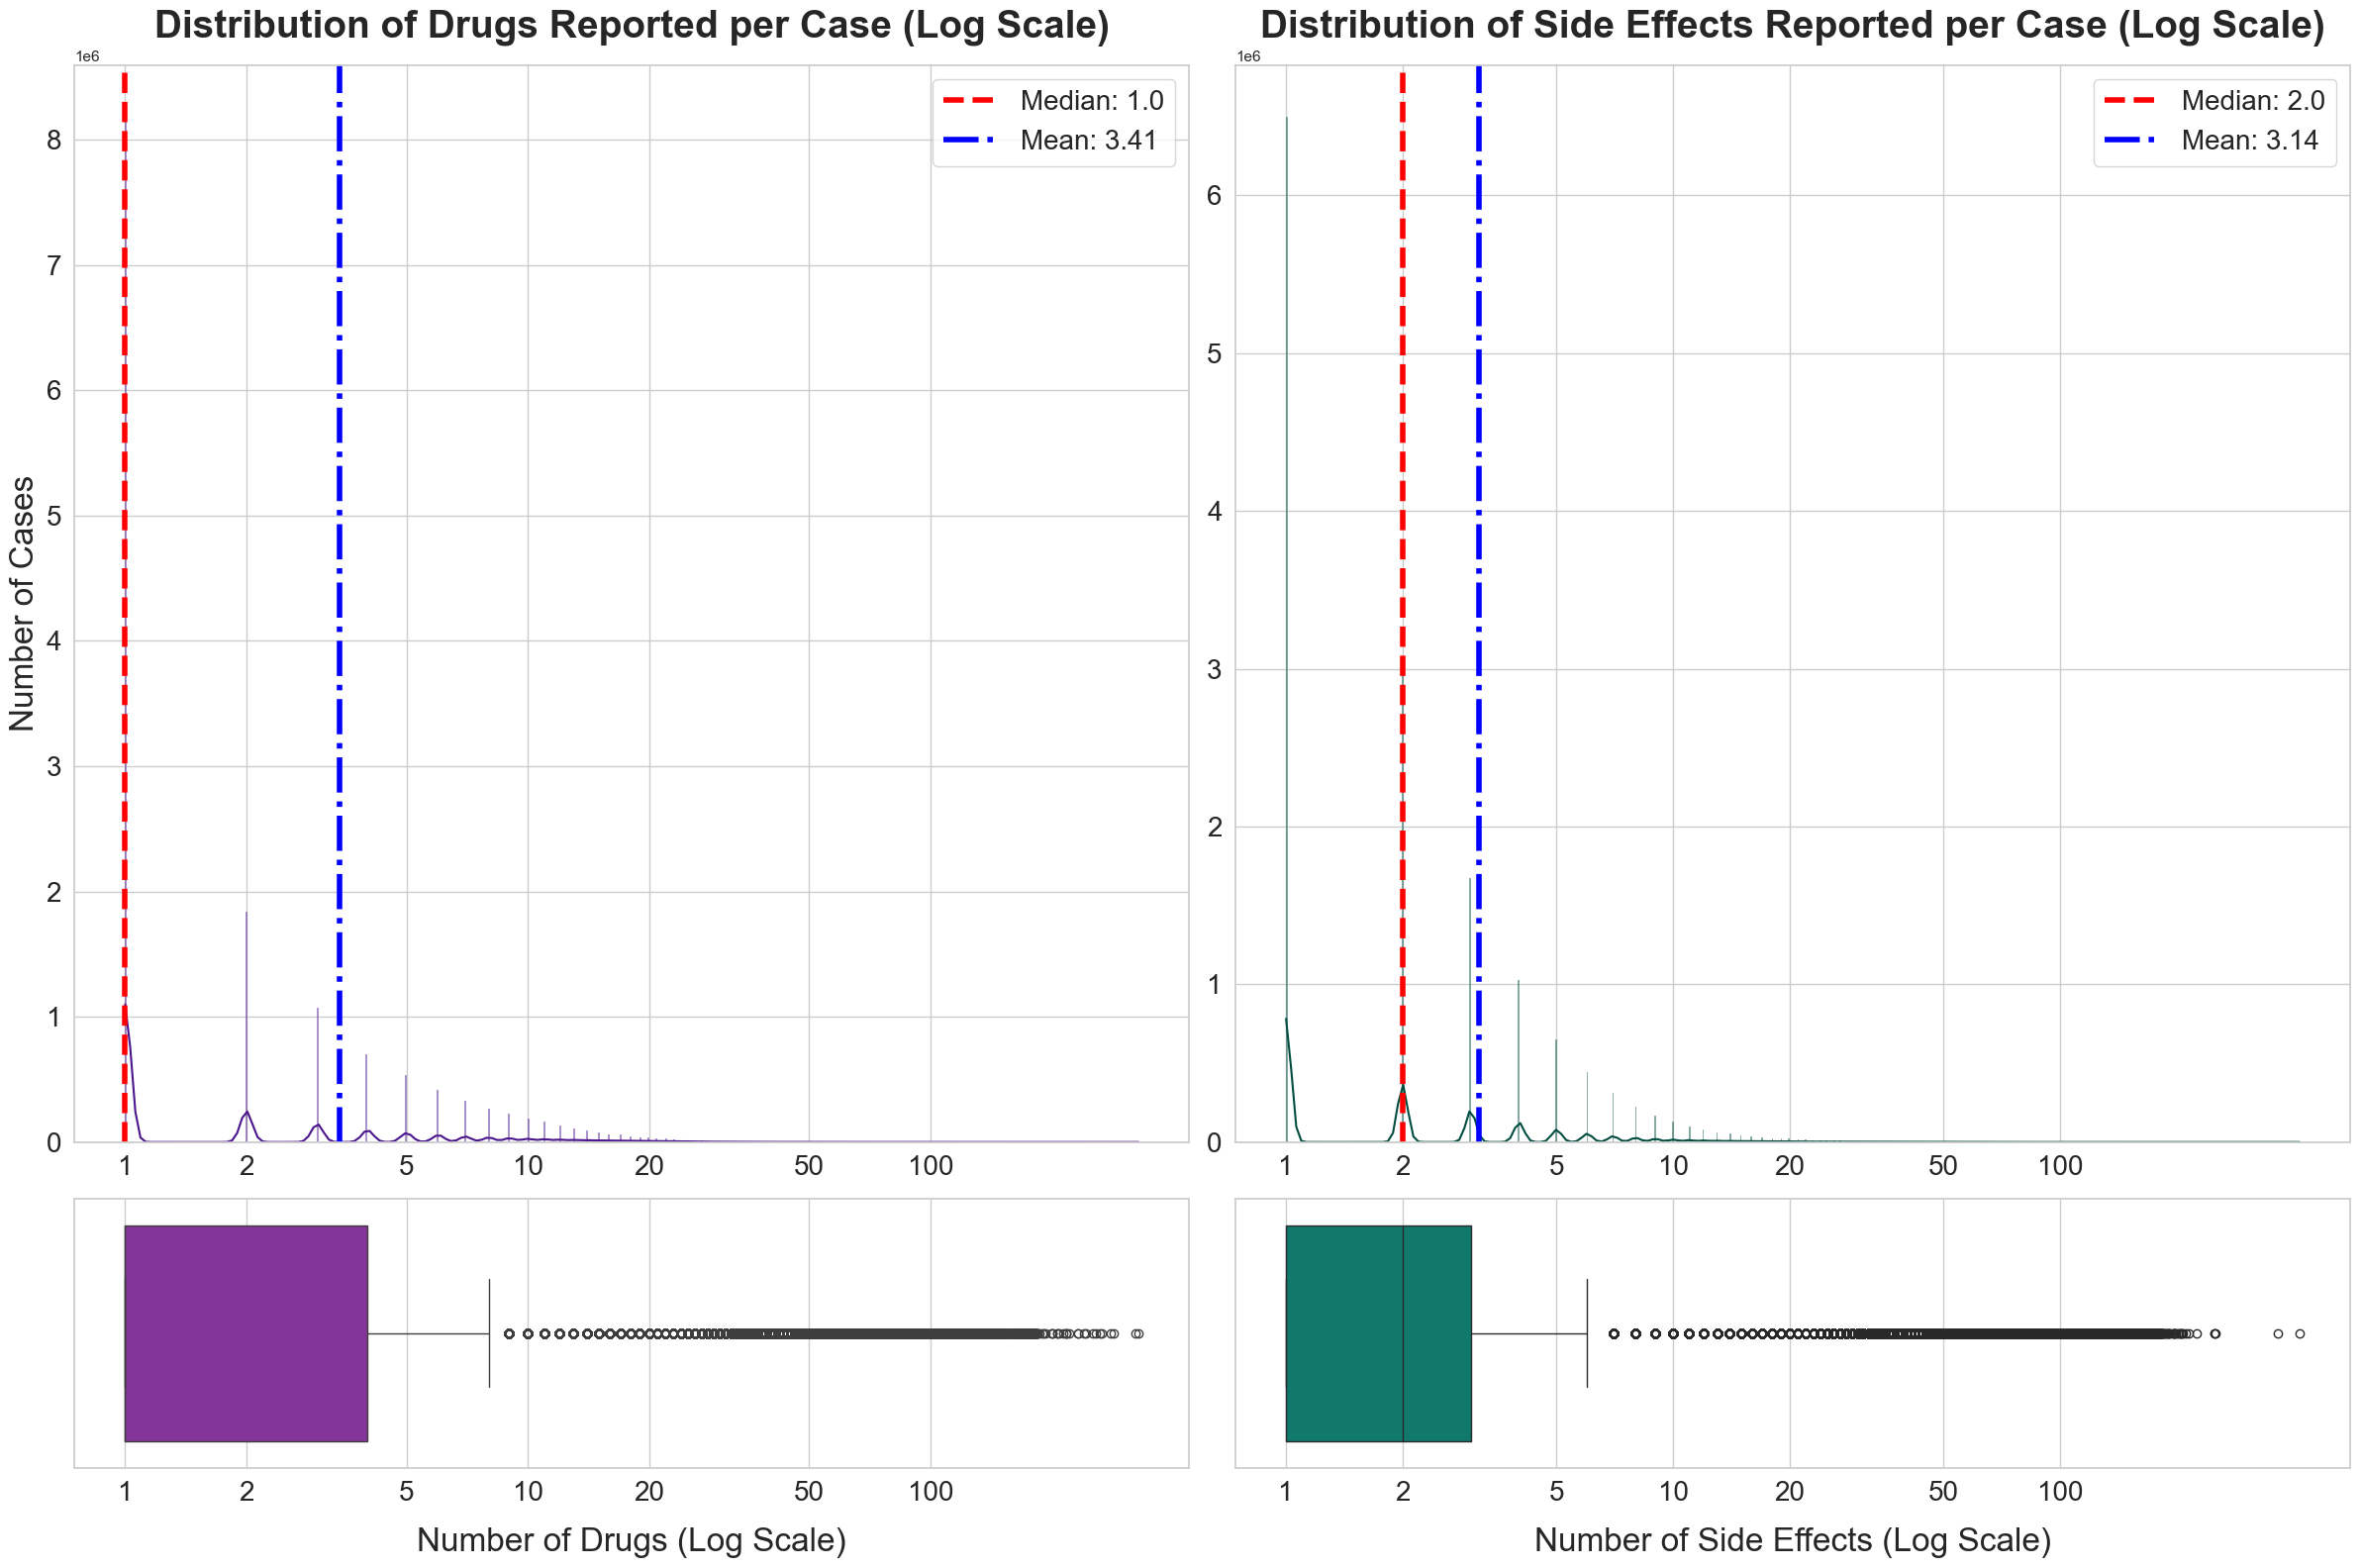

In [9]:
print("\nGenerating charts...")
from matplotlib.ticker import ScalarFormatter
sns.set_theme(style="whitegrid")

# Create 2x2 grid (Histograms on top, Boxplots on bottom)
fig, axes = plt.subplots(2, 2, figsize=(24, 16), gridspec_kw={"height_ratios": (.8, .2)})

df_drugs_filtered = df[df['drug_count'] > 0]
df_adr_filtered = df[df['adr_count'] > 0]

# --- A. DRUG DISTRIBUTION (LOG SCALE) ---
sns.histplot(data=df_drugs_filtered, x='drug_count', log_scale=True,
             kde=True, color='#4A148C', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Drugs Reported per Case (Log Scale)', fontsize=28, fontweight='bold', pad=20)
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Number of Cases', fontsize=24)
axes[0, 0].tick_params(labelsize=20)

# Add Mean Line (Blue) and Median Line (Red)
axes[0, 0].axvline(median_drugs, color='red', linestyle='--', linewidth=4, label=f"Median: {median_drugs:.1f}")
axes[0, 0].axvline(mean_drugs, color='blue', linestyle='-.', linewidth=4, label=f"Mean: {mean_drugs:.2f}")
axes[0, 0].legend(fontsize=20)

# Box Plot
sns.boxplot(data=df_drugs_filtered, x='drug_count', color='#8E24AA', ax=axes[1, 0])
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Number of Drugs (Log Scale)', fontsize=24, labelpad=15)
axes[1, 0].tick_params(labelsize=20)


# --- B. SIDE EFFECT DISTRIBUTION (LOG SCALE) ---
sns.histplot(data=df_adr_filtered, x='adr_count', log_scale=True, 
             kde=True, color='#004D40', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Side Effects Reported per Case (Log Scale)', fontsize=28, fontweight='bold', pad=20)
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(labelsize=20)

# Add Mean Line (Blue) and Median Line (Red)
axes[0, 1].axvline(median_adrs, color='red', linestyle='--', linewidth=4, label=f"Median: {median_adrs:.1f}")
axes[0, 1].axvline(mean_adrs, color='blue', linestyle='-.', linewidth=4, label=f"Mean: {mean_adrs:.2f}")
axes[0, 1].legend(fontsize=20)

# Box Plot
sns.boxplot(data=df_adr_filtered, x='adr_count', color='#00897B', ax=axes[1, 1])
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Number of Side Effects (Log Scale)', fontsize=24, labelpad=15)
axes[1, 1].tick_params(labelsize=20)


# Clean up ticks to display as whole numbers instead of scientific powers of 10
for ax in axes.flatten():
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100])

plt.tight_layout()
plt.show()